In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED = Path('../data/processed')

print(" Libraries loaded")

 Libraries loaded


In [2]:
from pathlib import Path

# Get absolute path regardless of where notebook runs from
BASE = Path('C:/Users/asus/Documents/ai-retail-intelligence-platform')
PROCESSED = BASE / 'data' / 'processed'

# Verify path exists
print(f"Path: {PROCESSED}")
print(f"Exists: {PROCESSED.exists()}")
print(f"Files: {[f.name for f in PROCESSED.glob('*.csv')]}")

Path: C:\Users\asus\Documents\ai-retail-intelligence-platform\data\processed
Exists: True
Files: ['customer_features.csv', 'geolocation_clean.csv', 'master_orders.csv', 'orders_clean.csv', 'orders_delivered.csv', 'products_clean.csv', 'reviews_clean.csv']


In [3]:
master    = pd.read_csv(PROCESSED / 'master_orders.csv', parse_dates=['order_purchase_timestamp'])
customers = pd.read_csv(PROCESSED / 'customer_features.csv')
products  = pd.read_csv(PROCESSED / 'products_clean.csv')
reviews   = pd.read_csv(PROCESSED / 'reviews_clean.csv')

print(f"Master orders : {master.shape}")
print(f"Customers     : {customers.shape}")
print(f"Products      : {products.shape}")
print(f"Reviews       : {reviews.shape}")

Master orders : (99441, 23)
Customers     : (96096, 10)
Products      : (32951, 10)
Reviews       : (99224, 7)


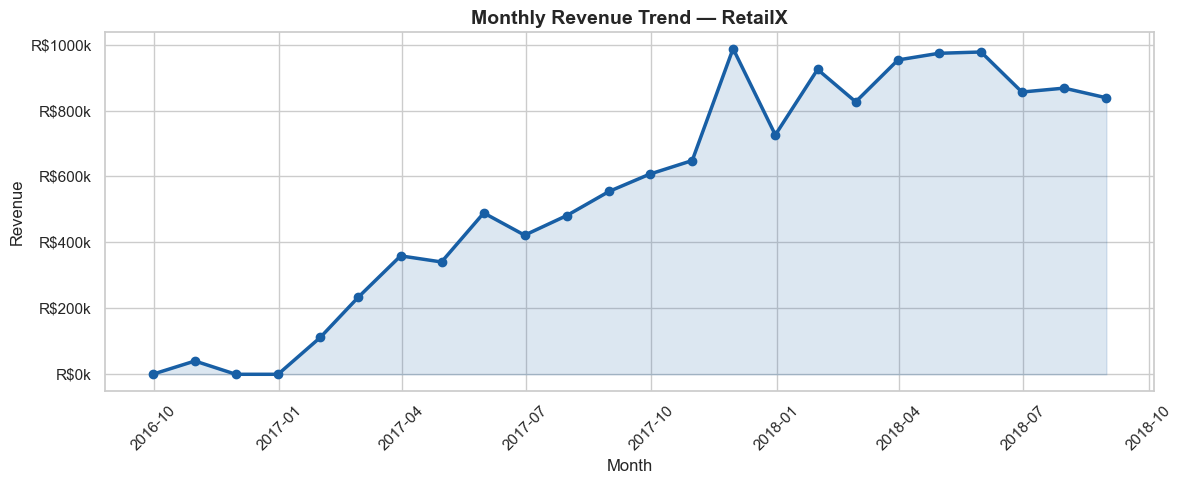

✅ Saved revenue_trend.png


In [4]:
monthly = (
    master[master['order_status'] == 'delivered']
    .set_index('order_purchase_timestamp')
    .resample('ME')['total_revenue']
    .sum()
    .reset_index()
)

SCREENSHOTS = Path('C:/Users/asus/Documents/ai-retail-intelligence-platform/screenshots')

fig, ax = plt.subplots()
ax.plot(monthly['order_purchase_timestamp'], monthly['total_revenue'],
        marker='o', linewidth=2.5, color='#185FA5')
ax.fill_between(monthly['order_purchase_timestamp'], monthly['total_revenue'],
                alpha=0.15, color='#185FA5')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax.set_title('Monthly Revenue Trend — RetailX', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'revenue_trend.png', dpi=150)
plt.show()
print("✅ Saved revenue_trend.png")

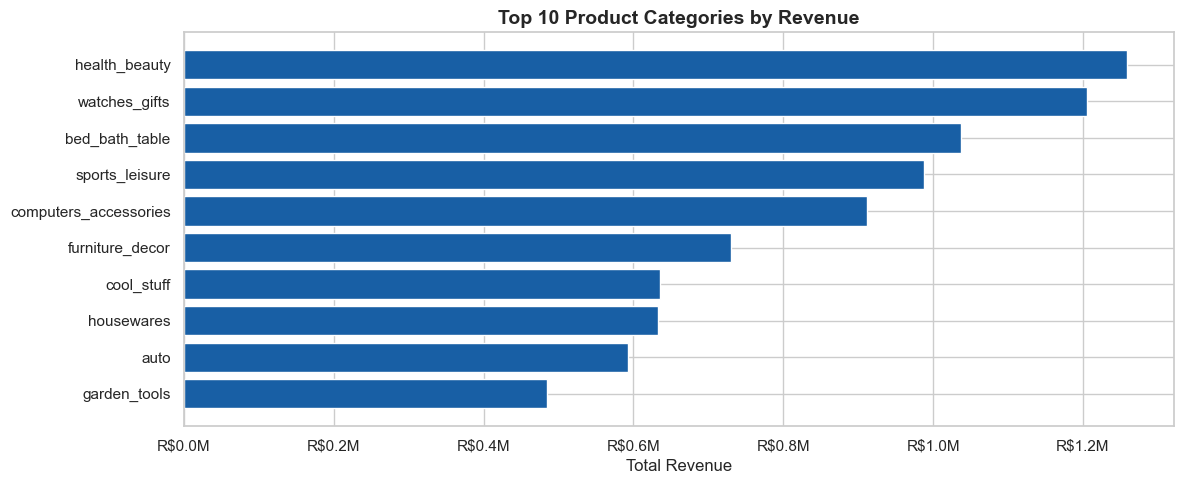

✅ Saved top_categories.png


In [5]:
RAW = Path('C:/Users/asus/Documents/ai-retail-intelligence-platform/data/raw')

cat_revenue = (
    pd.read_csv(PROCESSED / 'products_clean.csv')[['product_id','product_category_name_english']]
    .merge(pd.read_csv(RAW / 'olist_order_items_dataset.csv'), on='product_id')
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots()
ax.barh(cat_revenue['product_category_name_english'][::-1],
        cat_revenue['price'][::-1], color='#185FA5')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'top_categories.png', dpi=150)
plt.show()
print("✅ Saved top_categories.png")

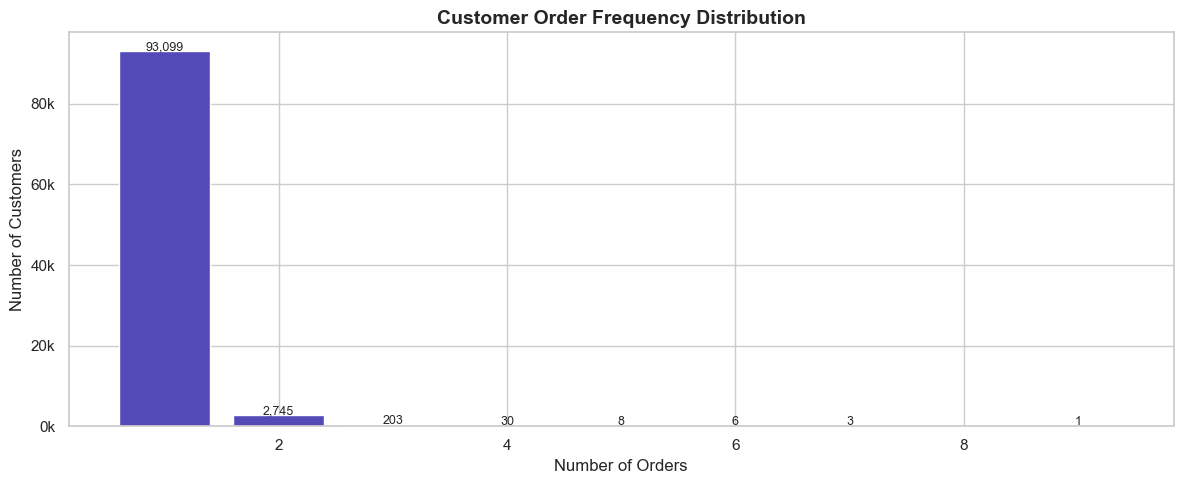

✅ Saved order_frequency.png


In [6]:
fig, ax = plt.subplots()
order_counts = customers['total_orders'].value_counts().sort_index().head(8)
ax.bar(order_counts.index, order_counts.values, color='#534AB7', edgecolor='white')
ax.set_title('Customer Order Frequency Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for idx, val in order_counts.items():
    ax.text(idx, val + 300, f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'order_frequency.png', dpi=150)
plt.show()
print("✅ Saved order_frequency.png")

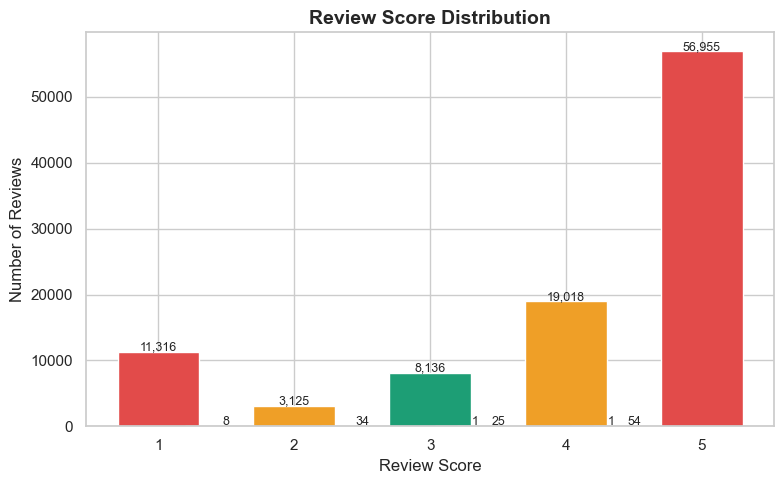

✅ Saved review_scores.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
score_counts = master['review_score'].value_counts().sort_index()
colors = ['#E24B4A','#E24B4A','#EF9F27','#1D9E75','#1D9E75']
bars = ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', width=0.6)
ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')
for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'review_scores.png', dpi=150)
plt.show()
print("✅ Saved review_scores.png")

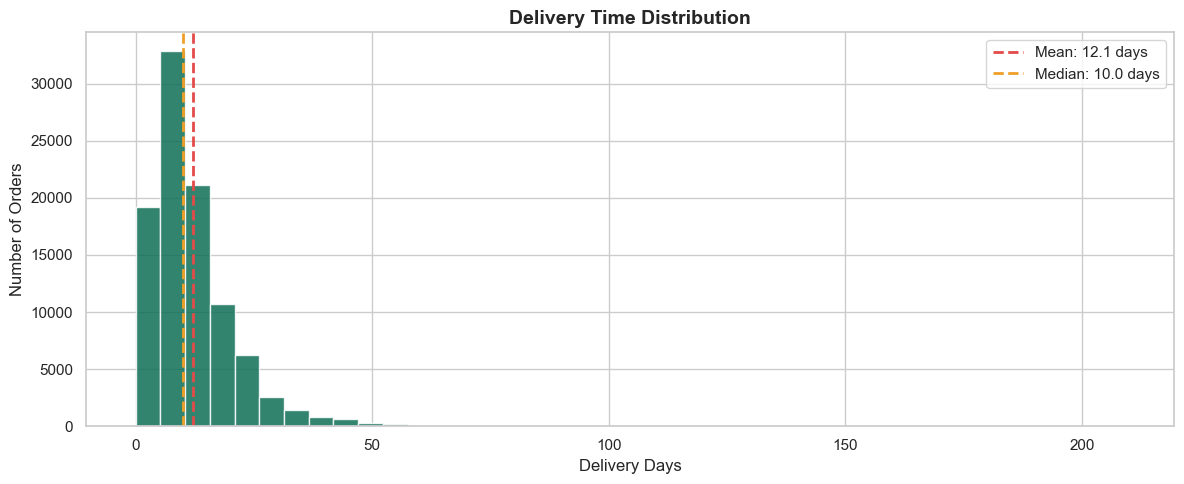

✅ Mean: 12.1 days | Median: 10.0 days


In [8]:
delivered = master[master['order_status'] == 'delivered']['delivery_days'].dropna()

fig, ax = plt.subplots()
ax.hist(delivered, bins=40, color='#0F6E56', edgecolor='white', alpha=0.85)
ax.axvline(delivered.mean(), color='#E24B4A', linestyle='--', linewidth=2,
           label=f'Mean: {delivered.mean():.1f} days')
ax.axvline(delivered.median(), color='#EF9F27', linestyle='--', linewidth=2,
           label=f'Median: {delivered.median():.1f} days')
ax.set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'delivery_distribution.png', dpi=150)
plt.show()
print(f"✅ Mean: {delivered.mean():.1f} days | Median: {delivered.median():.1f} days")

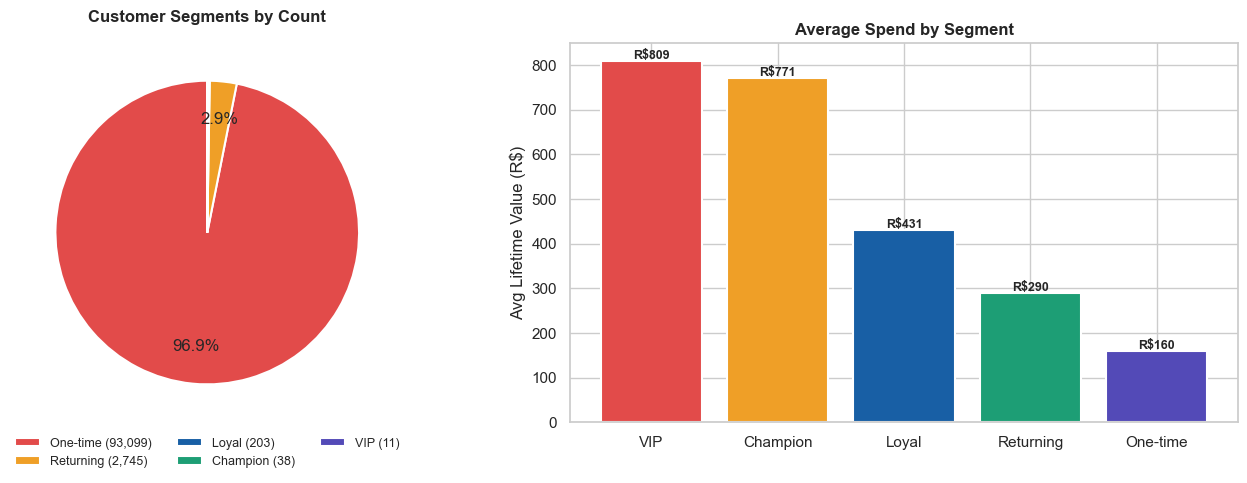

✅ Saved customer_segments.png


In [9]:
segments = customers.copy()
segments['segment'] = pd.cut(
    segments['total_orders'],
    bins=[0, 1, 2, 3, 5, 100],
    labels=['One-time', 'Returning', 'Loyal', 'Champion', 'VIP']
)

seg_counts = segments['segment'].value_counts()
colors_seg = ['#E24B4A','#EF9F27','#185FA5','#1D9E75','#534AB7']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — labels outside, small slices get % only inside
wedges, texts, autotexts = ax1.pie(
    seg_counts.values,
    labels=None,                    # remove inline labels
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    colors=colors_seg,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

# Legend outside the pie
ax1.legend(
    wedges,
    [f"{label} ({count:,})" for label, count in zip(seg_counts.index, seg_counts.values)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=9,
    frameon=False
)
ax1.set_title('Customer Segments by Count', fontweight='bold', pad=15)

# Bar chart
seg_value = segments.groupby('segment', observed=True)['total_spent'].mean().sort_values(ascending=False)
bars = ax2.bar(seg_value.index, seg_value.values, color=colors_seg[:len(seg_value)], 
               edgecolor='white', linewidth=1.5)
ax2.set_title('Average Spend by Segment', fontweight='bold')
ax2.set_ylabel('Avg Lifetime Value (R$)')

# Add value labels on bars
for bar, val in zip(bars, seg_value.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'R${val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(SCREENSHOTS / 'customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved customer_segments.png")

In [10]:
print("=" * 50)
print("  RETAILX — EDA SUMMARY")
print("=" * 50)
print(f"\n  Total orders     : {len(master):,}")
print(f"  Delivered orders : {(master['order_status']=='delivered').sum():,}")
print(f"  Total customers  : {len(customers):,}")
print(f"  Total revenue    : R${master['total_revenue'].sum():,.0f}")
print(f"  Avg order value  : R${master['total_revenue'].mean():,.2f}")
print(f"  Repeat rate      : {(customers['total_orders']>1).mean()*100:.1f}%")
print(f"  Avg delivery     : {master['delivery_days'].mean():.1f} days")
print(f"  5-star reviews   : {(master['review_score']==5).sum():,}")
print(f"  Churn rate       : {customers['is_churned'].mean()*100:.1f}%")
print("\n✅  EDA complete")

  RETAILX — EDA SUMMARY

  Total orders     : 99,441
  Delivered orders : 96,478
  Total customers  : 96,096
  Total revenue    : R$13,591,644
  Avg order value  : R$137.75
  Repeat rate      : 3.1%
  Avg delivery     : 12.1 days
  5-star reviews   : 56,955
  Churn rate       : 90.2%

✅  EDA complete
